In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('../Datasets/train.csv')

In [3]:
df.shape

(404290, 6)

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [6]:
df.sample(6)

,id,qid1,qid2,question1,question2,is_duplicate
114297,114297,149492,186604,What genre is Drake? Is he pop?,Is Drake music genre pop?,1
267237,267237,384564,384565,What is Richard Pipes' opinion on Trotsky duri...,Who was the Russian leader during World War 2?,0
58728,58728,102974,102975,TCS ELIGIBLITY FOR SELECTION OF FRESHERS?,How do I remove hard water stain from wine bot...,0
346695,346695,475074,475075,What is the job of a personal banker in HDFC b...,How much we can deposit in HDFC bank?,0
117167,117167,190711,125127,Why should I use Quora?,What is quora?,1
396088,396088,529125,101274,How do I impress a girl who is sitting beside ...,How do I talk to a girl without knowing her?,0


In [7]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['is_duplicate'].value_counts()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [10]:
(df['is_duplicate'].value_counts()/df['is_duplicate'].count() * 100)

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64

<Axes: xlabel='is_duplicate'>

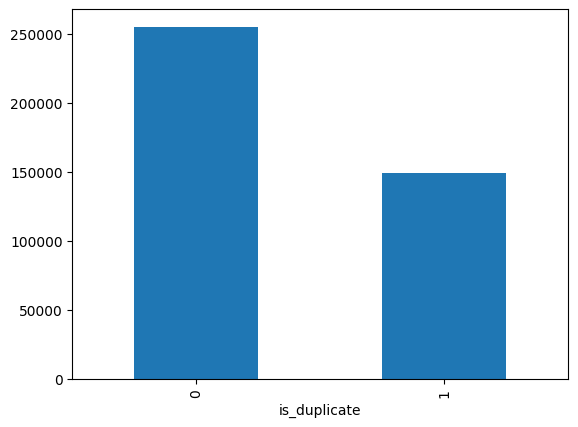

In [11]:
df['is_duplicate'].value_counts().plot(kind='bar')

In [12]:
uid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())

print("No. of Uniques Qs: ", np.unique(uid).shape[0]) 
x = uid.value_counts() > 1
print("No. of repeated Qs: ", x[x].shape[0])

No. of Uniques Qs:  537933
No. of repeated Qs:  111780


* Repeated questions Histogram

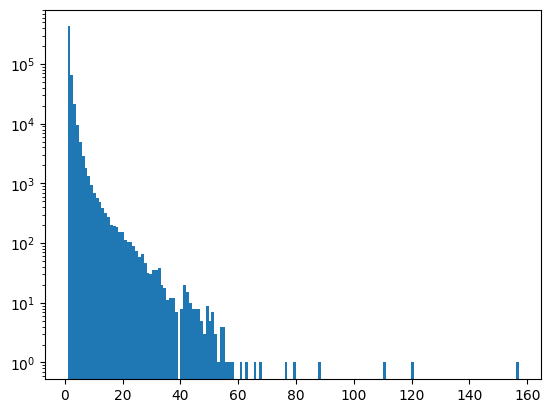

In [13]:

plt.hist(uid.value_counts().values, bins=160) 
plt.yscale('log') 
plt.show()

In [14]:
new_df = df.sample(50000,  random_state=2)

In [15]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [16]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [17]:
new_df.duplicated().sum()

np.int64(0)

In [18]:
new_df['is_duplicate'].value_counts()

is_duplicate
0    31601
1    18399
Name: count, dtype: int64

In [19]:
(new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count() * 100)

is_duplicate
0    63.202
1    36.798
Name: count, dtype: float64

<Axes: xlabel='is_duplicate'>

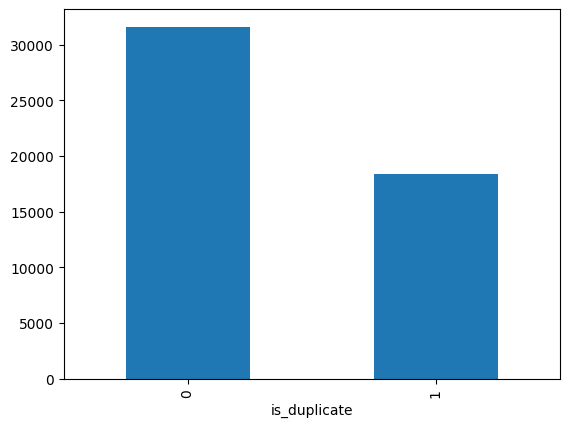

In [20]:
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [21]:

uid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())

print("No. of Uniques Qs: ", np.unique(uid).shape[0]) 
x = uid.value_counts() > 1
print("No. of repeated Qs: ", x[x].shape[0])

No. of Uniques Qs:  88945
No. of repeated Qs:  7384


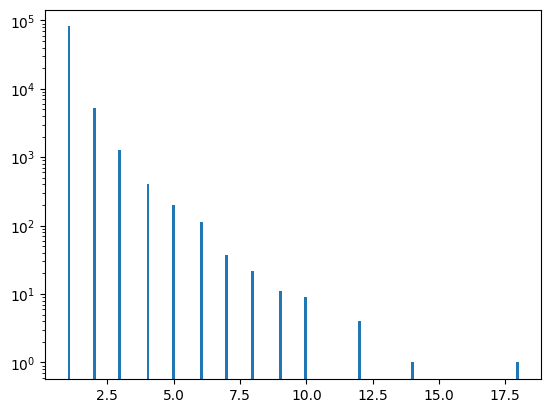

In [22]:
plt.hist(uid.value_counts().values, bins=160) 
plt.yscale('log') 
plt.show()

## Feature Engineering

In [23]:
new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [24]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50


In [25]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(' ')))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(' ')))

In [26]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9


In [27]:
def commor_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [28]:
new_df['words_common'] = new_df.apply(commor_words, axis= 1)

In [29]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3


In [30]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [31]:
new_df['total_words'] = new_df.apply(total_words, axis= 1)

In [32]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13


In [33]:
new_df['word_share'] = round((new_df['words_common']/new_df['total_words']), 2) 

In [34]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1,76,77,12,12,11,24,0.46
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0,49,57,12,15,7,23,0.30
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0,105,120,25,17,2,34,0.06
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0,59,146,12,30,0,32,0.00
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0,35,50,5,9,3,13,0.23


Minimum chars:  1
Max chars:  391
Average chars:  59


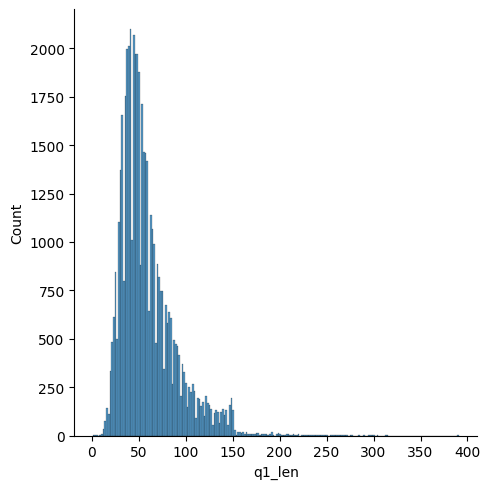

In [35]:
# Analysis of Features 
sns.displot(new_df['q1_len'])
print("Minimum chars: ", new_df['q1_len'].min())
print("Max chars: ", new_df['q1_len'].max())
print("Average chars: ", int(new_df['q1_len'].mean()))

C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\3770048840.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['words_common'], label='Non Duplicate')
C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\3770048840.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dis

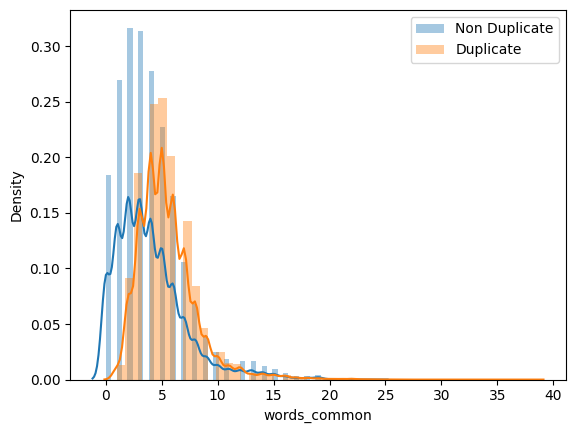

In [36]:
# Common Words

sns.distplot(new_df[new_df['is_duplicate'] == 0]['words_common'], label='Non Duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['words_common'], label='Duplicate')
plt.legend()
plt.show()

C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\3370345924.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['total_words'], label='Non Duplicate')
C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\3370345924.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

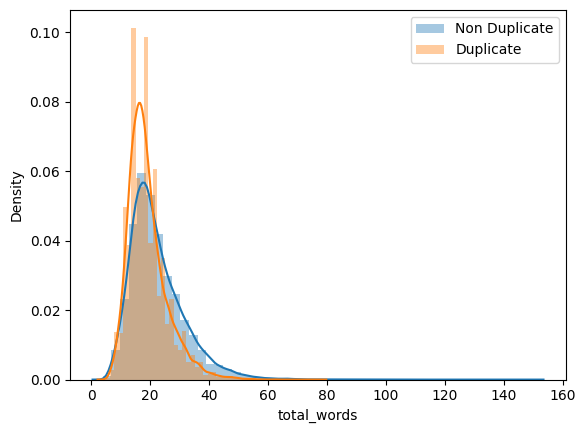

In [37]:
# Total Words

sns.distplot(new_df[new_df['is_duplicate'] == 0]['total_words'], label='Non Duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['total_words'], label='Duplicate')
plt.legend()
plt.show()

C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\1999654960.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label='Non Duplicate')
C:\Users\Ragnar\AppData\Local\Temp\ipykernel_7820\1999654960.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distp

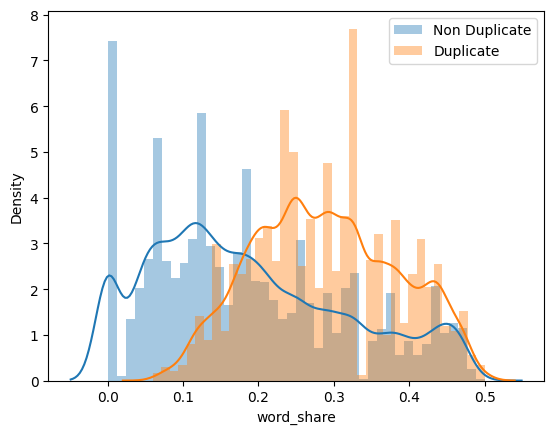

In [38]:
# Share Words

sns.distplot(new_df[new_df['is_duplicate'] == 0]['word_share'], label='Non Duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]['word_share'], label='Duplicate')
plt.legend()
plt.show()

In [39]:
question_df = new_df[['question1', 'question2']] 
question_df.head()

,question1,question2
398782,What is the best marketing automation tool for...,What is the best marketing automation tool for...
115086,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...
327711,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...
367788,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...
151235,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...


In [40]:
final_df = new_df.drop(columns=['id', 'qid1', 'qid2', 'question1', 'question2'])

In [41]:
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share
398782,1,76,77,12,12,11,24,0.46
115086,0,49,57,12,15,7,23,0.30
327711,0,105,120,25,17,2,34,0.06
367788,0,59,146,12,30,0,32,0.00
151235,0,35,50,5,9,3,13,0.23


In [42]:
final_df.shape

(50000, 8)

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

In [44]:
# Merge Text 
questions = list(question_df['question1']) + list(question_df['question2']) 

In [45]:
cv = CountVectorizer(max_features=3000) 
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [46]:
temp_df1 = pd.DataFrame(q1_arr, index = question_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = question_df.index)

In [47]:
temp_df = pd.concat([temp_df1, temp_df2], axis= 1)

In [48]:
temp_df.shape

(50000, 6000)

In [49]:
final_df = pd.concat([final_df, temp_df], axis = 1)

In [50]:
final_df.shape

(50000, 6008)

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train, x_test, y_train, y_test = train_test_split(final_df.iloc[:, 1:].values, final_df.iloc[:, 0].values, test_size = 0.2, random_state = 42)

In [53]:
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,24,0.46,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,23,0.30,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,34,0.06,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,32,0.00,0,0,...,0,0,1,0,0,0,0,0,0,0
151235,0,35,50,5,9,3,13,0.23,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [55]:
rf  = RandomForestClassifier()

In [56]:
rf.fit(x_train, y_train) 
y_pred = rf.predict(x_test)
accuracy_score(y_test, y_pred) * 100

77.75

In [57]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)
accuracy_score(y_test, y_pred) * 100

77.36

In [60]:
questions[:10]

['What is the best marketing automation tool for small and mid-size companies?',
 'I am poor but I want to invest. What should I do?',
 'I am from India and live abroad. I met a guy from France in a party.I want to date him. How do I do that?',
 'Why do so many people in the U.S. hate the southern states?',
 'Consequences of Bhopal gas tragedy?',
 "I killed a snake on a Friday. There's a belief that when you kill a snake on a Friday it will certainly take revenge. Will I be killed?",
 'Is the royal family a net gain or a net loss to the British taxpayer?',
 'If a huge asteroid was about to hit Earth in X year, would we be able to find survival solutions in due time?',
 'What would happen if a woman took Viagra?',
 'How could I improve my love to my girlfriend?']

In [61]:
new_final_df = final_df.drop(columns=['total_words'])

In [62]:
new_final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,words_common,word_share,0,1,2,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
398782,1,76,77,12,12,11,0.46,0,0,0,...,0,0,0,0,0,0,0,0,0,0
115086,0,49,57,12,15,7,0.30,0,0,0,...,0,0,0,0,0,0,0,0,0,0
327711,0,105,120,25,17,2,0.06,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367788,0,59,146,12,30,0,0.00,0,0,0,...,0,0,1,0,0,0,0,0,0,0
151235,0,35,50,5,9,3,0.23,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
x_train, x_test, y_train, y_test = train_test_split(new_final_df.iloc[:, 1:].values, new_final_df.iloc[:, 0].values, test_size=0.2, random_state=42) 

In [66]:
rf1 = RandomForestClassifier() 
rf1.fit(x_train, y_train) 
y_pred = rf1.predict(x_test)
accuracy_score(y_test, y_pred) * 100

77.16

In [67]:
xgb1 = XGBClassifier()
xgb1.fit(x_train, y_train)
y_pred = xgb1.predict(x_test)
accuracy_score(y_test, y_pred) * 100

77.42999999999999